<style>
.reveal { font-family: 'Segoe UI', system-ui, sans-serif; }
.reveal h2 { color: #0D2240; border-bottom: 2.5px solid #1A7A9A;
             padding-bottom:.15em; margin-bottom:.5em; }
.reveal .slides section { text-align: left; }
.reveal pre { font-size:.62em; border-radius:6px; border:1px solid #E2E6EE; box-shadow:none; }
.reveal pre code { max-height:420px; }
.reveal ul li, .reveal ol li { margin-bottom:.3em; }
.defn { background:#EAF6FA; border-left:4px solid #1A7A9A;
        padding:.6em 1em; border-radius:0 6px 6px 0; margin:.5em 0; }
.nota { background:#FFF8E1; border-left:4px solid #C8961E;
        padding:.6em 1em; border-radius:0 6px 6px 0; margin:.5em 0; }
</style>

## Ley de Grandes Números y Teorema del Límite Central
### Modelado de Sistemas bajo Incertidumbre · Semana 2
---
Departamento de Ingeniería Industrial · Universidad de los Andes

## Agenda
1. Ley de los Grandes Números (LGN) — intuición y enunciado formal
2. Visualización de la convergencia
3. Teorema del Límite Central (TLC) — enunciado e interpretación
4. ¿Por qué el TLC justifica Monte Carlo?
5. Intervalos de confianza para estimadores de simulación
6. ¿Cuántas réplicas necesito?

## Ley de los Grandes Números
<div class="defn">

**LGN débil:** Sea $X_1, X_2, \ldots$ i.i.d. con $\mathbb{E}[X] = \mu < \infty$. Entonces:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu \quad (n \to \infty)$$

</div>

**Consecuencia para simulación:** con suficientes réplicas, el promedio muestral converge al valor esperado real, **independientemente de la distribución** de $X$.

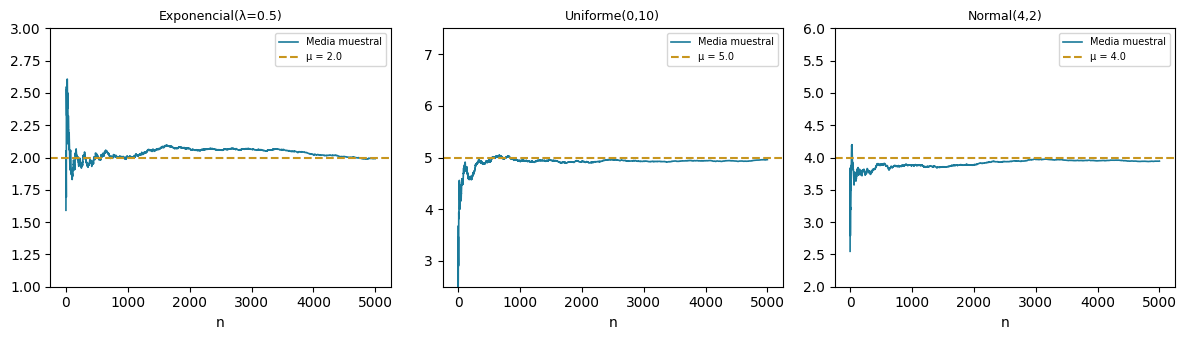

In [1]:
import numpy as np, matplotlib.pyplot as plt
np.random.seed(0)
n_max = 5000
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
configs = [
    (np.random.exponential, (2,),     'Exponencial(λ=0.5)', 2.0),
    (np.random.uniform,     (0, 10),  'Uniforme(0,10)',      5.0),
    (np.random.normal,      (4, 2),   'Normal(4,2)',         4.0),
]
for ax, (fn, args, label, mu) in zip(axes, configs):
    samples = fn(*args, n_max)
    medias  = np.cumsum(samples) / np.arange(1, n_max+1)
    ax.plot(medias, '#1A7A9A', lw=1.2, label='Media muestral')
    ax.axhline(mu, color='#C8961E', ls='--', lw=1.5, label=f'μ = {mu}')
    ax.set_title(label, fontsize=9); ax.set_xlabel('n'); ax.legend(fontsize=7)
    ax.set_ylim(mu*0.5, mu*1.5)
plt.tight_layout(); plt.show()

## Teorema del Límite Central
<div class="defn">

Sea $X_1, \ldots, X_n$ i.i.d. con media $\mu$ y varianza $\sigma^2 < \infty$. Entonces:

$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1) \quad (n\to\infty)$$

</div>

**Clave:** la distribución de $\bar{X}_n$ es aproximadamente normal **sin importar la distribución** de $X_i$, cuando $n$ es suficientemente grande.

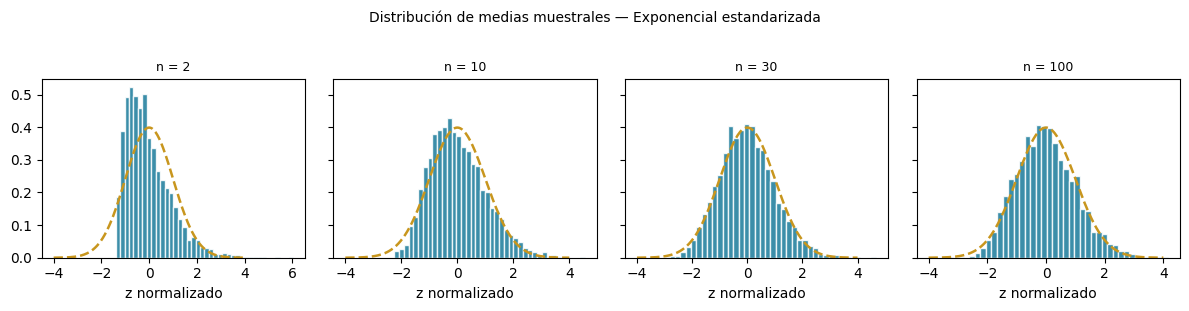

In [2]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm
np.random.seed(2)

n_exp, ns = 3000, [2, 10, 30, 100]
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

for ax, n in zip(axes, ns):
    medias = [np.mean(np.random.exponential(2, n)) for _ in range(n_exp)]
    medias = np.array(medias)
    z = (medias - 2) / (2/np.sqrt(n))
    ax.hist(z, bins=40, density=True, color='#1A7A9A', edgecolor='white', alpha=.85)
    x = np.linspace(-4, 4, 200)
    ax.plot(x, norm.pdf(x), '#C8961E', lw=1.8, ls='--')
    ax.set_title(f'n = {n}', fontsize=9); ax.set_xlabel('z normalizado')
plt.suptitle('Distribución de medias muestrales — Exponencial estandarizada', y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

## Intervalos de Confianza en Simulación
Si ejecuto $n$ réplicas independientes con resultados $Y_1, \ldots, Y_n$:

$$\bar{Y} \pm t_{n-1,\,\alpha/2} \cdot \frac{S}{\sqrt{n}}$$

donde $S^2 = \frac{1}{n-1}\sum(Y_i - \bar{Y})^2$.

**Interpretación:** con $(1-\alpha)\times 100\%$ de confianza, el parámetro real $\mu$ cae en ese intervalo.

In [3]:
import numpy as np
from scipy.stats import t
np.random.seed(8)

def ic_montecarlo(generador, n_replicas, alpha=0.05):
    y = np.array([generador() for _ in range(n_replicas)])
    media = y.mean(); s = y.std(ddof=1)
    tc = t.ppf(1 - alpha/2, df=n_replicas-1)
    error = tc * s / np.sqrt(n_replicas)
    return media, media - error, media + error

# Ejemplo: costo esperado con incertidumbre en tiempos de servicio
def simular_costo():
    tiempo = np.random.exponential(10)       # min/cliente
    costo_espera = tiempo * np.random.uniform(500, 1500)  # $/min
    return costo_espera

for n in [10, 100, 500, 2000]:
    media, li, ls = ic_montecarlo(simular_costo, n)
    print(f"n={n:5d}  media={media:8.1f}  IC=[{li:8.1f}, {ls:8.1f}]  ancho={ls-li:7.1f}")

n=   10  media= 10769.7  IC=[  4163.4,  17376.0]  ancho=13212.6
n=  100  media= 10570.4  IC=[  8159.1,  12981.6]  ancho= 4822.5
n=  500  media= 10202.9  IC=[  9179.3,  11226.5]  ancho= 2047.3
n= 2000  media=  9617.1  IC=[  9164.2,  10070.0]  ancho=  905.8


## ¿Cuántas Réplicas Necesito?
Para lograr un error máximo $\varepsilon$ con confianza $(1-\alpha)$:

$$n^* = \left\lceil \left(\frac{t_{\alpha/2} \cdot S}{\varepsilon}\right)^2 \right\rceil$$

**Proceso iterativo** (piloto → estimar $S$ → calcular $n^*$ → ejecutar réplicas adicionales)

<div class="nota">
Duplicar la precisión requiere <strong>cuatro veces</strong> más réplicas — el error estándar decrece como $1/\sqrt{n}$.
</div>

## Conclusiones
- La **LGN** garantiza que el promedio de simulación converge al valor real
- El **TLC** garantiza que podemos construir intervalos de confianza con la distribución normal
- Juntos, justifican rigurosamente el método Monte Carlo
- Siempre reportar el resultado de simulación con su **intervalo de confianza**: un número sin IC no es una respuesta completa